In [5]:
!nvidia-smi

Thu Sep  4 09:04:56 2025       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 511.65       Driver Version: 511.65       CUDA Version: 11.6     |
|-------------------------------+----------------------+----------------------+
| GPU  Name            TCC/WDDM | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ... WDDM  | 00000000:01:00.0  On |                  N/A |
| N/A   50C    P0   128W /  N/A |   5766MiB / 16384MiB |    100%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils import data
from torchvision import utils, datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
BATCH_SIZE=60000
transform = transforms.Compose([transforms.ToTensor()])
tr_ds=datasets.MNIST('./data/', train=True, download=True, transform=transform)
tr_ds_loader = data.DataLoader(dataset=tr_ds, batch_size=BATCH_SIZE, shuffle=False)
img, _ = next(iter(tr_ds_loader))
# 평균과 표준편차 계산
img.mean(), img.std()

(tensor(0.1307), tensor(0.3081))

In [4]:
BATCH_SIZE=64
EPOCHS=10

In [5]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    # transforms.Normalize((0.1307,),(0.3081,)) # 흐릿하게 만들어버림
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [6]:
tr_ds.data[:1].shape

torch.Size([1, 28, 28])

In [7]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3),
        )
        self.decoder = nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [8]:
autoencoder = AutoEncoder().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(), lr=5e-3)
criterion = nn.MSELoss()

In [9]:
v_img = tr_ds.data[:5].view(-1,28*28)
v_img = v_img.type(torch.FloatTensor)/255.
v_img.shape

torch.Size([5, 784])

In [10]:
def train(m, tr_ds_loader):
    m.train()
    for i, (x,y) in enumerate(tr_ds_loader):
        data = x.view(-1, 28*28).to(DEVICE)
        target = x.view(-1, 28*28).to(DEVICE)
        label = y.to(DEVICE)

        en, de = m(data) # 인코딩값과 디코딩값이 나옴

        loss = criterion(de, target)
        opt.zero_grad()
        loss.backward()
        opt.step()

1회


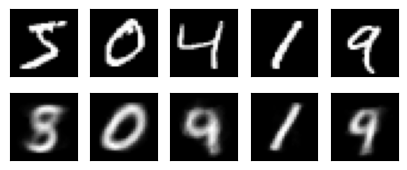

2회


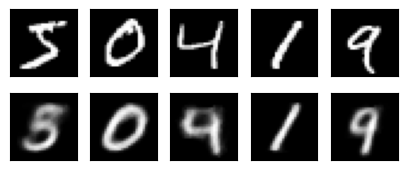

3회


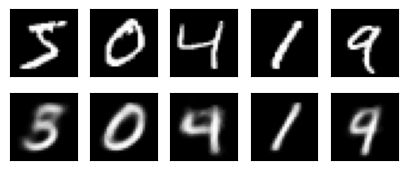

4회


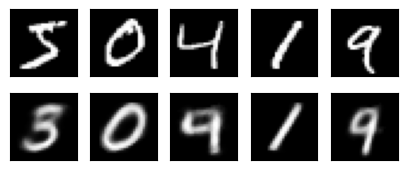

5회


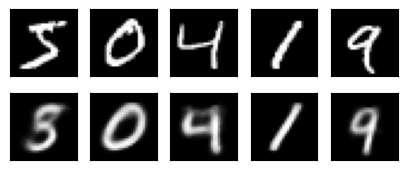

6회


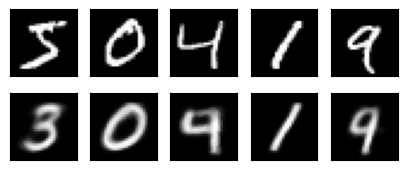

7회


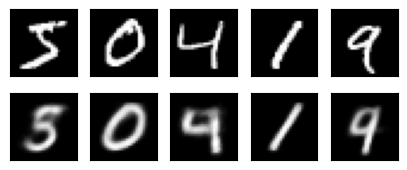

8회


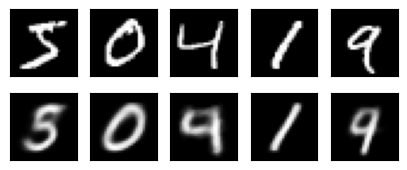

9회


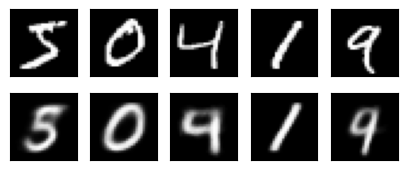

10회


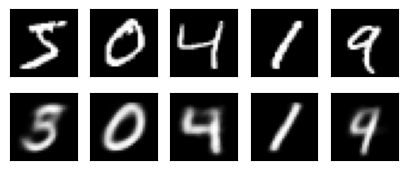

In [11]:
for epoch in range(1, EPOCHS+1):
    train(autoencoder, tr_ds_loader)

    tt_x = v_img.to(DEVICE)
    _, de = autoencoder(tt_x)
    fig, ax = plt.subplots(2,5,figsize=(5,2))
    print(f"{epoch}회")
    for i in range(5):
        img = v_img.to('cpu').data.numpy()[i].reshape(28,28)
        ax[0][i].imshow(img, cmap='gray')
        ax[0][i].set_xticks(())
        ax[0][i].set_yticks(())

    for i in range(5):
        img = de.to('cpu').data.numpy()[i].reshape(28,28)
        ax[1][i].imshow(img, cmap='gray')
        ax[1][i].set_xticks(())
        ax[1][i].set_yticks(())
    plt.show()

# 패션 MNIST 데이터를 이용하여 오토인코더를 설계하고 학습하시오

In [32]:
tr_ds = datasets.FashionMNIST('./data/',train=True,download=True,transform=transform)

In [33]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    # transforms.Normalize((0.1307,),(0.3081,)) # 흐릿하게 만들어버림
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [34]:
tr_ds.data[:1].shape

torch.Size([1, 28, 28])

In [35]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3),
        )
        self.decoder = nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [36]:
autoencoder = AutoEncoder().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(), lr=5e-3)
criterion = nn.MSELoss()

In [37]:
v_img = tr_ds.data[:5].view(-1,28*28)
v_img = v_img.type(torch.FloatTensor)/255.
v_img.shape

torch.Size([5, 784])

In [38]:
def train(m, tr_ds_loader):
    m.train()
    for i, (x,y) in enumerate(tr_ds_loader):
        data = x.view(-1, 28*28).to(DEVICE)
        target = x.view(-1, 28*28).to(DEVICE)
        label = y.to(DEVICE)

        en, de = m(data) # 인코딩값과 디코딩값이 나옴

        loss = criterion(de, target)
        opt.zero_grad()
        loss.backward()
        opt.step()

1회


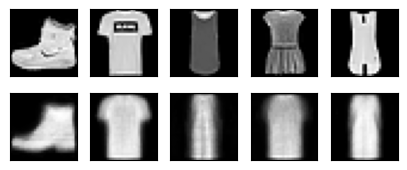

2회


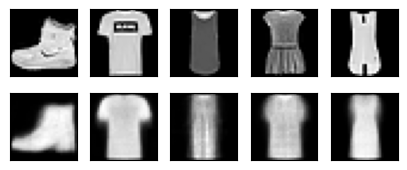

3회


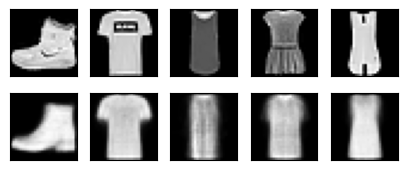

4회


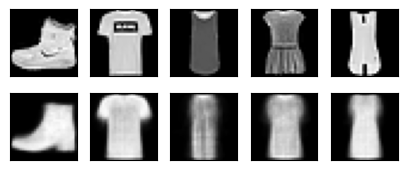

5회


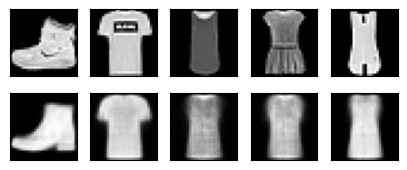

6회


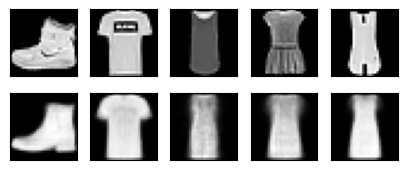

7회


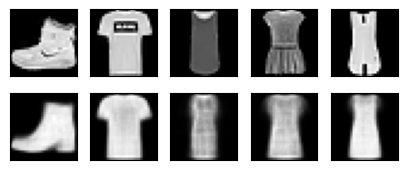

8회


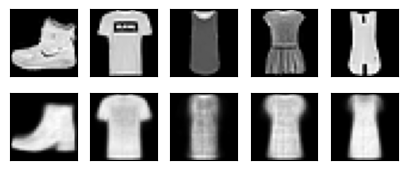

9회


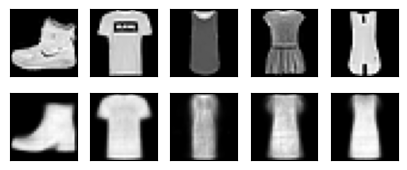

10회


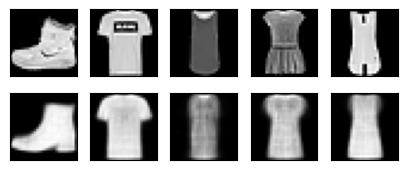

In [39]:
for epoch in range(1, EPOCHS+1):
    train(autoencoder, tr_ds_loader)

    tt_x = v_img.to(DEVICE)
    _, de = autoencoder(tt_x)
    fig, ax = plt.subplots(2,5,figsize=(5,2))
    print(f"{epoch}회")
    for i in range(5):
        img = v_img.to('cpu').data.numpy()[i].reshape(28,28)
        ax[0][i].imshow(img, cmap='gray')
        ax[0][i].set_xticks(())
        ax[0][i].set_yticks(())

    for i in range(5):
        img = de.to('cpu').data.numpy()[i].reshape(28,28)
        ax[1][i].imshow(img, cmap='gray')
        ax[1][i].set_xticks(())
        ax[1][i].set_yticks(())
    plt.show()

# 강사님 수업

In [29]:
tr_ds = datasets.FashionMNIST(root='./data/', train=True, download=False, transform=transforms.ToTensor())
tr_ds_loader = data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

In [30]:
autoencoder = AutoEncoder().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(), lr=5e-3)
criterion = nn.MSELoss()

In [31]:
def add_noise(img): # 일부러 이미지를 망가뜨리기 위한 노이즈 추가 함수
    noise = torch.randn(img.size())*0.2
    noise_img = img + noise
    return noise_img

In [40]:
def train(m, tr_ds_loader):
    m.train()
    avg_loss = 0
    for i, (x,y) in enumerate(tr_ds_loader):
        data = x.view(-1, 28*28).to(DEVICE)
        target = x.view(-1, 28*28).to(DEVICE)
        label = y.to(DEVICE)

        en, de = m(data) # 인코딩값과 디코딩값이 나옴

        loss = criterion(de, target)
        opt.zero_grad()
        loss.backward()
        opt.step()

        avg_loss += loss.item()
    return avg_loss/len(tr_ds_loader)

In [41]:
for epoch in range(1, EPOCHS+1):
    loss = train(autoencoder, tr_ds_loader)
    print(f'{epoch}회 loss: {loss}')

1회 loss: 0.022038854398468793
2회 loss: 0.021884347681504195
3회 loss: 0.021785616934267695
4회 loss: 0.02169373586400549
5회 loss: 0.02184266916144568
6회 loss: 0.021616955212295563
7회 loss: 0.021681641848054902
8회 loss: 0.02158162291687943
9회 loss: 0.021562600101250957
10회 loss: 0.02162376289039469


In [42]:
tt_ds = datasets.FashionMNIST(root='./data/', train=False, download=False, transform=transforms.ToTensor())
tr_ds_loader = data.DataLoader(tt_ds, batch_size=BATCH_SIZE, shuffle=True)
sample_data = tt_ds.data[0].view(-1, 28*28)
sample_data = sample_data.type(torch.FloatTensor)/255.
oj_data = sample_data[0]
noise_data = add_noise(oj_data).to(DEVICE)
_, output = autoencoder(noise_data)

In [45]:
output.shape, oj_data.shape, noise_data.shape

(torch.Size([784]), torch.Size([784]), torch.Size([784]))

(28, 28) (28, 28) (28, 28)


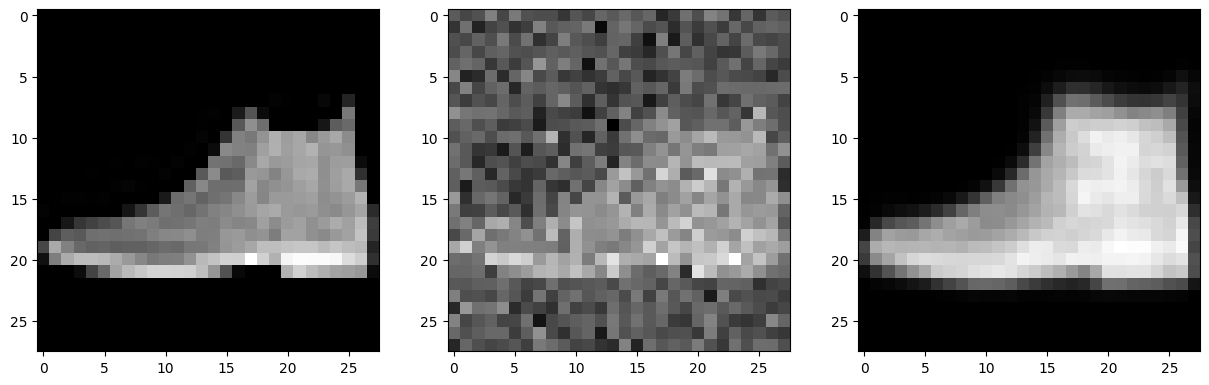

In [51]:
fig, ax = plt.subplots(1,3, figsize=(15,15))
oj_img = oj_data.to('cpu').data.numpy().reshape(28,28)
noisy_img = noise_data.to('cpu').data.numpy().reshape(28,28)
output_img = output.to('cpu').data.numpy().reshape(28,28)
print(oj_img.shape, noisy_img.shape, output_img.shape)
ax[0].imshow(oj_img, cmap='gray')
ax[1].imshow(noisy_img, cmap='gray')
ax[2].imshow(output_img, cmap='gray')
plt.show()

In [52]:
tr_ds = datasets.FashionMNIST(root='./data/', train=True, download=False, transform=transforms.ToTensor())
tr_ds_loader = data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
tt_ds = datasets.FashionMNIST(root='./data/', train=False, download=False, transform=transforms.ToTensor())
tr_ds_loader = data.DataLoader(tt_ds, batch_size=BATCH_SIZE, shuffle=True)

In [85]:
G = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()
)

In [86]:
D = nn.Sequential(
    nn.Linear(784, 256),
    nn.LeakyReLU(0.2), # 기울기를 얼마나 줄 것인지 입력해줘야함. 기본값은 0.01
    nn.Linear(256, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

In [87]:
G = G.to(DEVICE)
D = D.to(DEVICE)

In [88]:
criterion = nn.BCELoss()
d_opt = optim.Adam(D.parameters(), lr=2e-4)
g_opt = optim.Adam(G.parameters(), lr=2e-4)

In [89]:
EPOCHS=300
for epoch in range(EPOCHS):
    for i,(x,_) in enumerate(tr_ds_loader):
        #data=x.reshape(-1,784).to(DEVICE)
        
        data=x.reshape(BATCH_SIZE,-1).to(DEVICE)
        #print(data.shape[-1])
        if data.shape[-1]!=784:
            continue
        r_label=torch.ones(BATCH_SIZE,1).to(DEVICE)
        f_label=torch.zeros(BATCH_SIZE,1).to(DEVICE)
        #1. 진짜 데이터 판별
        #print(data.shape)
        output=D(data)
        d_loss_real=criterion(output,r_label)
        real_sc=output

        z=torch.randn(BATCH_SIZE,64).to(DEVICE)
        f_data=G(z)

        #2. 가짜 데이터 판별
        output=D(f_data)
        d_loss_fake=criterion(output,f_label)
        fake_sc=output
        #판별오차 토출
        d_loss=d_loss_real+d_loss_fake

        #초기화
        g_opt.zero_grad()
        d_opt.zero_grad()
        #판별자 학습
        d_loss.backward()
        d_opt.step()

        #생성오차 도출
        f_data=G(z)
        output=D(f_data)
        g_loss=criterion(output,r_label)
        

        #생성자 학습
        g_opt.zero_grad()
        d_opt.zero_grad()
        g_loss.backward()
        g_opt.step()
        
    print(f"{epoch}회 d_loss{d_loss.item()},g_loss{g_loss.item()}, D(G(z)):{fake_sc.mean()},D(x):{real_sc.mean()}")

0회 d_loss0.2505943179130554,g_loss3.2503600120544434, D(G(z)):0.11533910036087036,D(x):0.8964935541152954
1회 d_loss0.13736307621002197,g_loss4.627839088439941, D(G(z)):0.05088217556476593,D(x):0.9229049682617188
2회 d_loss0.12510645389556885,g_loss6.112135887145996, D(G(z)):0.03544662892818451,D(x):0.9283797740936279
3회 d_loss0.20127981901168823,g_loss5.3103742599487305, D(G(z)):0.07937879860401154,D(x):0.9028204679489136
4회 d_loss0.11341018974781036,g_loss3.848388671875, D(G(z)):0.06800427287817001,D(x):0.9641239047050476
5회 d_loss0.6091181039810181,g_loss2.016879081726074, D(G(z)):0.3446345329284668,D(x):0.8842915296554565
6회 d_loss0.25272035598754883,g_loss2.890239953994751, D(G(z)):0.10824207961559296,D(x):0.9204226136207581
7회 d_loss0.12048602104187012,g_loss4.521594047546387, D(G(z)):0.03206928074359894,D(x):0.9345774054527283
8회 d_loss0.10594500601291656,g_loss4.6980299949646, D(G(z)):0.06878210604190826,D(x):0.9703285098075867
9회 d_loss0.17523080110549927,g_loss4.63978385925293,

7분 11초 걸림;;

In [90]:
z = torch.randn(BATCH_SIZE, 64, device=DEVICE)
ck_img1 = G(z)
ck_img1.shape

torch.Size([64, 784])

In [91]:
G1 = nn.Sequential(
    nn.Linear(64, 256),
    nn.ReLU(),
    nn.Linear(256,256),
    nn.ReLU(),
    nn.Linear(256, 784),
    nn.Tanh()
)
G1 = G1.to(DEVICE)
G1_opt = optim.Adam(G1.parameters(), lr=2e-4)

In [92]:
ck_img2 = G1(z)
ck_img2.shape

torch.Size([64, 784])

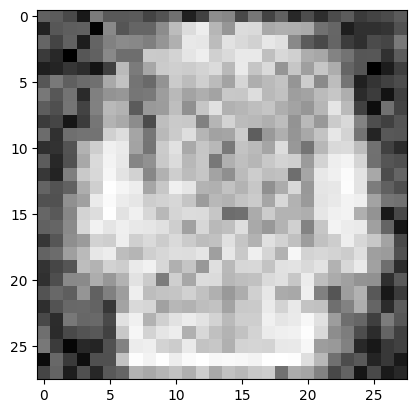

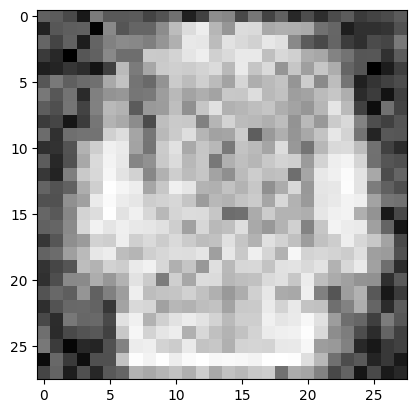

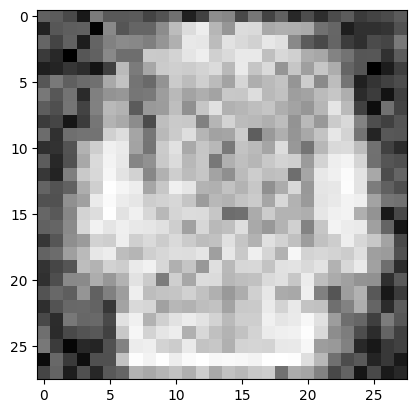

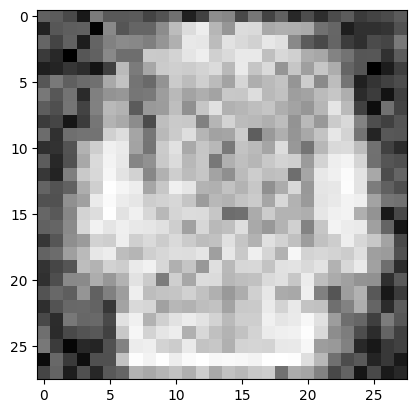

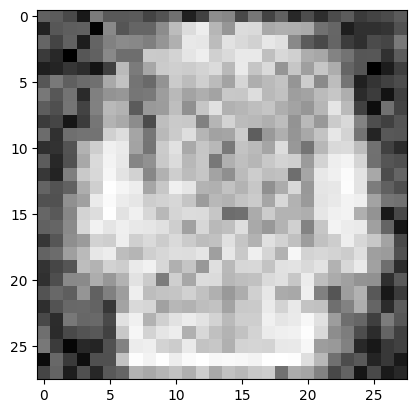

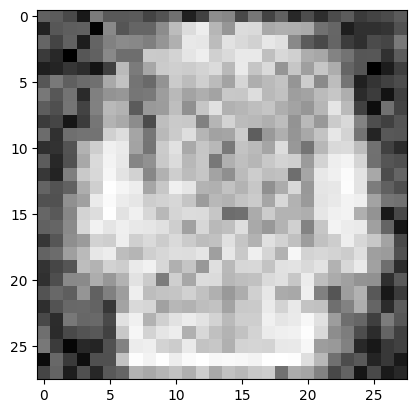

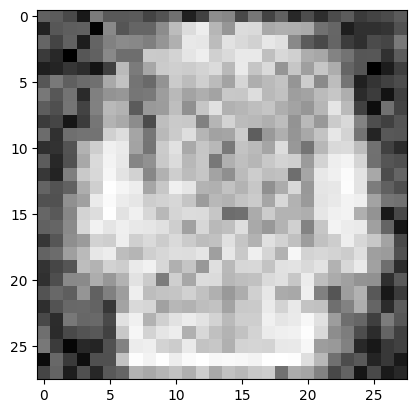

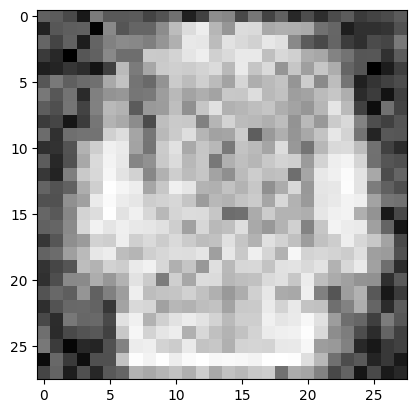

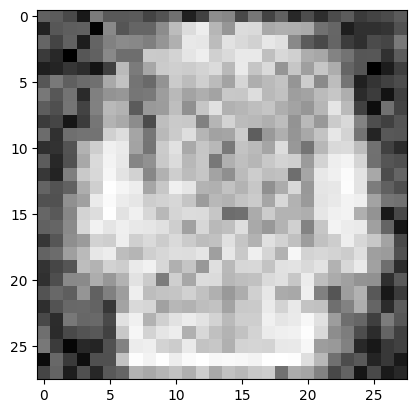

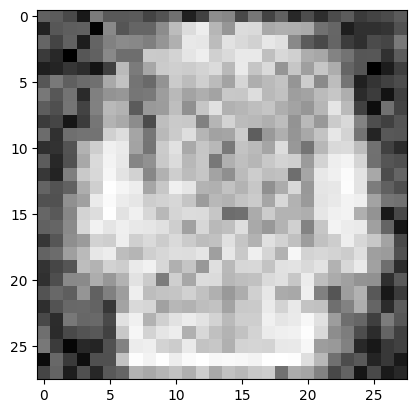

In [94]:
for i in range(10):
    plt.imshow(ck_img1.data.cpu().numpy()[1].reshape(28,28), cmap='gray')
    plt.show()

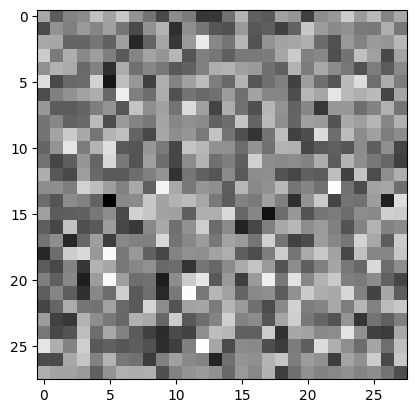

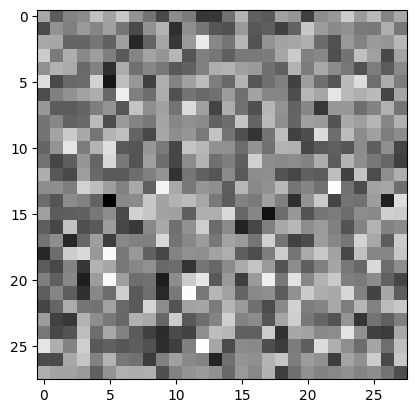

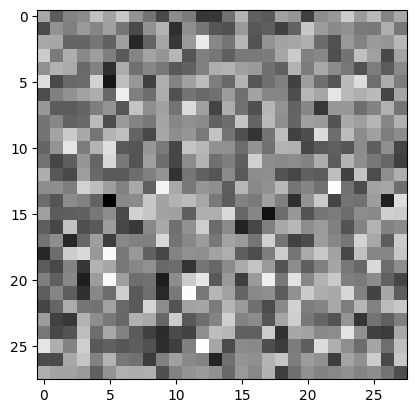

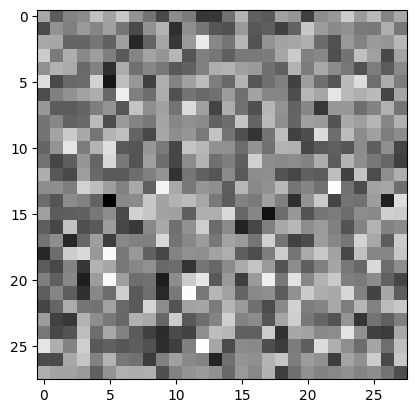

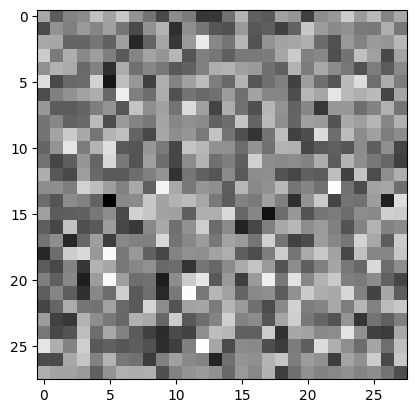

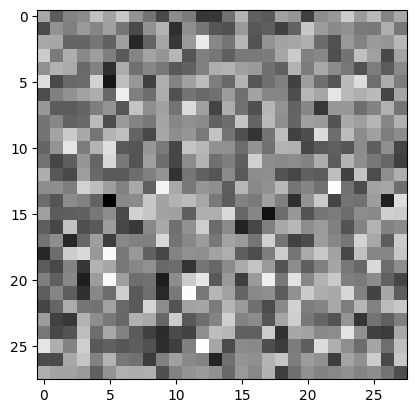

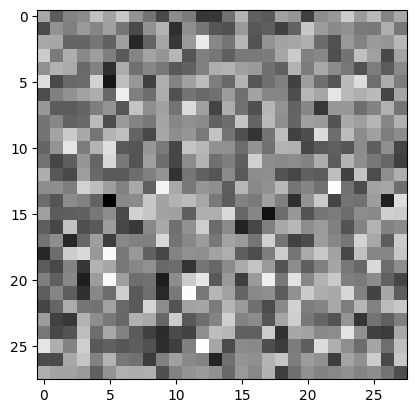

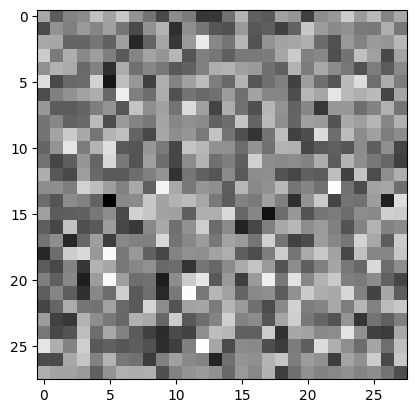

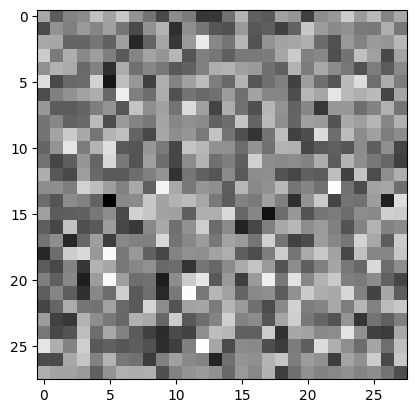

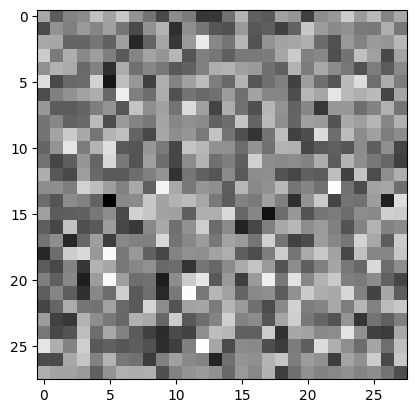

In [95]:
for i in range(10):
    plt.imshow(ck_img2.data.cpu().numpy()[1].reshape(28,28), cmap='gray')
    plt.show()

In [ ]:
nn.ConvTranspose2d # 뉴런을 복원시키는 역할을 함

# MNIST 데이터를 이용하여 GAN 모델을 만들어 학습 후 결과를 출력하시오
1. 데이터 로드 (데이터 분할 시 남는 갯수없이 만들기 <배치 크기 선정)
2. 판별자와 생성자의 모양은 자유롭게, 단 너무 깊게는 미권장
3. 학습의 에폭은 30으로 한정

In [158]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils import data
from torchvision import utils, datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

In [159]:
BATCH_SIZE = 128 # 원래 100으로 하면 아무 문제없이 할 수 있긴 함(이건 데이터를 알기에 할 수 있는 설정임)
EPOCHS = 30

In [160]:
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,),(0.5,))])
tr_ds_loader = data.DataLoader(
    dataset=datasets.MNIST('./data/', train=True, download=False, transform=transform),
    batch_size=128, shuffle=False # , drop_last=True 이거 쓰면 학습할때 에러 회피 가능
)

In [161]:
gen = nn.Sequential(
    nn.Linear(BATCH_SIZE, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 784),
    nn.Tanh(),
)

In [162]:
des = nn.Sequential(
    nn.Linear(784, 512),
    nn.LeakyReLU(0.1),
    nn.Linear(512, 256),
    nn.LeakyReLU(0.1),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

In [163]:
gen = gen.to(DEVICE)
des = des.to(DEVICE)
gen_opt = optim.Adam(gen.parameters(), lr=2e-4)
des_opt = optim.Adam(des.parameters(), lr=2e-4)
criterion = nn.BCELoss()

In [164]:
for epoch in range(EPOCHS):
    for i, (x,_) in enumerate(tr_ds_loader):
        try:
            gen_opt.zero_grad()
            des_opt.zero_grad()
            dat = x.reshape(BATCH_SIZE, -1).to(DEVICE)
            r_label = torch.ones(BATCH_SIZE, 1, device=DEVICE)
            f_label = torch.zeros(BATCH_SIZE, 1, device=DEVICE)

            output = des(dat)
            des_r_loss = criterion(output, r_label)
            real_sc = output

            z = torch.randn(BATCH_SIZE, BATCH_SIZE, device=DEVICE)
            f_data = gen(z)

            output = des(f_data)
            des_f_loss = criterion(output, f_label)
            fake_sc = output
            d_loss = des_f_loss + des_r_loss

            d_loss.backward()
            des_opt.step()

            f_data = gen(z)
            output = des(f_data)
            g_loss = criterion(output, r_label)

            gen_opt.zero_grad()
            des_opt.zero_grad()
            g_loss.backward()
            gen_opt.step()
        except:
            pass
    print(f"epoch{epoch}\t d_loss:{d_loss.item()}\tg_loss{g_loss.item()} D(G(z)):{fake_sc.mean()}\tD(x):{real_sc.mean()}")

epoch0	 d_loss:0.05974267050623894	g_loss5.518728256225586 D(G(z)):0.023713070899248123	D(x):0.9710862636566162
epoch1	 d_loss:0.6485550999641418	g_loss1.6771823167800903 D(G(z)):0.3652694821357727	D(x):0.8900235891342163
epoch2	 d_loss:1.5486350059509277	g_loss1.1650593280792236 D(G(z)):0.4848361015319824	D(x):0.5911068916320801
epoch3	 d_loss:0.5415544509887695	g_loss1.9858492612838745 D(G(z)):0.32008489966392517	D(x):0.9017751216888428
epoch4	 d_loss:0.338751882314682	g_loss3.342116355895996 D(G(z)):0.09736056625843048	D(x):0.8905456066131592
epoch5	 d_loss:0.3221898674964905	g_loss2.625622272491455 D(G(z)):0.2034303843975067	D(x):0.9548027515411377
epoch6	 d_loss:0.2748403549194336	g_loss3.608814239501953 D(G(z)):0.05551272630691528	D(x):0.902640700340271
epoch7	 d_loss:0.4295192062854767	g_loss5.470693588256836 D(G(z)):0.06561918556690216	D(x):0.8486210703849792
epoch8	 d_loss:0.17278945446014404	g_loss3.8318443298339844 D(G(z)):0.05779600888490677	D(x):0.9335371851921082
epoch9	 

In [165]:
temp = torch.randn(BATCH_SIZE, BATCH_SIZE, device=DEVICE)
test_img = gen(temp)

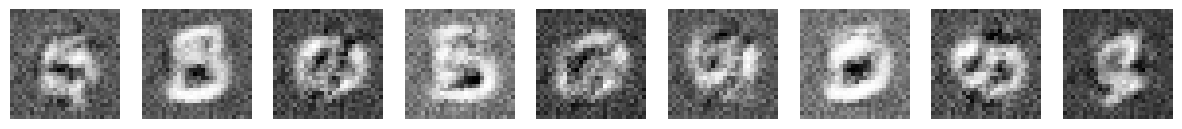

In [134]:
plt.figure(figsize=(15,6))
for i in range(9):
    plt.subplot(1,9,i+1)
    plt.imshow(test_img.data.cpu().numpy()[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

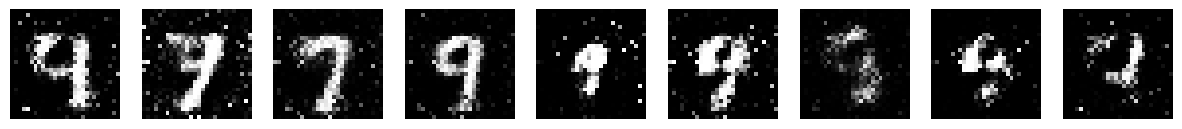

In [166]:
plt.figure(figsize=(15,6))
for i in range(9):
    plt.subplot(1,9,i+1)
    plt.imshow(test_img.data.cpu().numpy()[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()

In [ ]:
z_dim = 100
G = nn.Sequential(
    nn.Linear(100, 1*28*28),
    nn.ConvTranspose2d()
)

In [151]:
out = G(torch.tensor([[1. for i in range(100)]]))
out1 = G(torch.FloatTensor([1 for i in range(100)]))
out.shape, out1.shape

(torch.Size([1, 784]), torch.Size([784]))

In [152]:
tr_img = out.reshape(1,1,28,28)
tr_img.shape

torch.Size([1, 1, 28, 28])

In [153]:
tr_ds.data[:1].shape

torch.Size([1, 28, 28])

In [157]:
D = nn.Sequential( # 1, 28, 28 
    nn.Conv2d(1, 12, kernel_size=3, padding=1), # 12, 26, 26
    nn.MaxPool2d(2),  # 12, 13, 13
    nn.Conv2d(12, 24, kernel_size=3, padding=1, stride=2), # 24, 11, 11
    nn.MaxPool2d(2) # 24, 5, 5
)
# D(tr_ds.data[:1].reshape(1, 1, 28, 28))
for i in tr_ds_loader:
    print(D(i[0]).shape)
    break

torch.Size([128, 24, 3, 3])
